### 2-1. 결측치 처리

In [1]:
# 결측치 확인
import pandas as pd
import numpy as np

wine = pd.read_csv('https://raw.githubusercontent.com/algoboni/pythoncodebook1-1/main/2-1_wine.csv',
                   index_col=0).filter(['Alcohol', 'Malicacid', 'Ash', 'Magnesium', 'Hue'])

wine.isna().sum()


Alcohol      0
Malicacid    0
Ash          0
Magnesium    0
Hue          0
dtype: int64

*   결측치가 없음을 확인함
*   아래는 결측치를 생성하는 코드임

In [2]:
import numpy as np
wine_m = wine.copy()
display(wine_m.isna().sum())

np.random.seed(42)
print(wine_m.sample(24).index)
wine_m.loc[wine_m.sample(24).index, 'Alcohol'] = np.nan

np.random.seed(74)
print(wine_m.sample(24).index)
wine_m.loc[wine_m.sample(24).index, 'Ash'] = np.nan

display(wine_m.isna().sum())



Alcohol      0
Malicacid    0
Ash          0
Magnesium    0
Hue          0
dtype: int64

Int64Index([ 19,  45, 140,  30,  67,  16, 119, 174, 109, 141,  24, 150,  41,
            118,  15, 111, 113,  82,   9, 114,  18,  66,  60, 169],
           dtype='int64')
Int64Index([172,  16, 145, 108,  84, 142, 136, 149, 127,  69, 157,  65, 133,
             51, 110,  17, 112,  15, 134, 161, 130,  14,  58, 141],
           dtype='int64')


Alcohol      24
Malicacid     0
Ash          24
Magnesium     0
Hue           0
dtype: int64

In [3]:
# Plotting 환경설정
# !rm -rf ~/.cache/matplotlib
import matplotlib.font_manager as fm

# fm.findSystemFonts(fontpaths=None, fontext='ttf')
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothicLight.ttf')
# fm.fontManager.ttflist

import matplotlib.pyplot as plt

plt.rc('figure', figsize=(10, 6))
plt.rc('font', family='NanumGothic')
plt.rc('font', size=12)
plt.rc('axes.spines', top=False, right=False)
plt.rc('axes', unicode_minus=False)

fig, ax = plt.subplots(1,2, figsize=(8,4)) ; plt.subplots_adjust(wspace=0.5)

import missingno as msno
msno.matrix(df=wine, figsize=(5,5), fontsize=12, ax=ax[0])
ax[0].set_ylabel('원본 데이터')

msno.matrix(df=wine_m, figsize=(5,5), fontsize=12, ax=ax[1])
ax[1].set_ylabel('결측치 생성 데이터')

AttributeError: 'FontManager' object has no attribute 'addfont'

In [4]:
# 결측치 보간 - Zero & Consdtant Imputation

wine_imp = wine_m.fillna(1000)
msno.matrix(df=wine_imp, figsize=(1,1), fontsize=5, sparkline=False)



NameError: name 'msno' is not defined

In [5]:
# 결측치 보간 - 중심값
from sklearn.impute import SimpleImputer

mean_imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
median_imputer = SimpleImputer(missing_values=np.nan, strategy='median')
mode_imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

wine_imp_mean = pd.DataFrame(mean_imputer.fit_transform(wine_m), columns=wine_m.columns)
wine_imp_median = pd.DataFrame(median_imputer.fit_transform(wine_m), columns=wine_m.columns)
wine_imp_mode = pd.DataFrame(mode_imputer.fit_transform(wine_m), columns=wine_m.columns)

fig, ax = plt.subplots(1,3, figsize=(12,4)) ; plt.subplots_adjust(wspace=0.5)
msno.matrix(df=wine_imp_mean, figsize=(1,1), fontsize=12, sparkline=False, ax=ax[0])
msno.matrix(df=wine_imp_median, figsize=(1,1), fontsize=12, sparkline=False, ax=ax[1])
msno.matrix(df=wine_imp_mode, figsize=(1,1), fontsize= 12, sparkline=False, ax=ax[2])


NameError: name 'plt' is not defined

In [ ]:
# 결측치 보간 - 단순확률대치법

wine_m2 = wine_m.copy()



*   Hot-deck 대치법은 현재 진행중인 연구에서 비슷한 성향을 갖는 데이터들 중 랜던하게 선택하는 방법
*   Cold-deck 대치법은 외부 출처 혹은 이전의 비슷한 연구에서 대체할 자료를 가져오는 것



In [ ]:
np.random.seed(42)
idx_m = wine_m2.query('Alcohol.isna()').index
fillValues = wine.query('not Alcohol.isna()').Alcohol.sample(24).values

np.random.seed(453)
idx_m = wine_m2.query('Ash.isna()').index
fillValues = wine.query('not Ash.isna()').Ash.sample(24).values

wine_m2.loc[idx_m, 'Ash'] = fillValues
wine_m2.isna().sum()

,0
Alcohol,24
Malicacid,0
Ash,0
Magnesium,0
Hue,0


In [ ]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
wine_m3 = pd.DataFrame(imputer.fit_transform(wine_m), columns=wine_m.columns)
wine_m3.isna().sum()

,0
Alcohol,0
Malicacid,0
Ash,0
Magnesium,0
Hue,0


In [ ]:
wine_m_idx = wine_m.query('Ash.isna() or Alcohol.isna()').index
wine_m.query('Ash.isna() or Alcohol.isna()')

,Alcohol,Malicacid,Ash,Magnesium,Hue
2,13.16,2.36,NaN,101,1.03
8,14.83,1.64,NaN,97,1.08
9,NaN,1.35,2.27,98,1.01
12,NaN,1.73,2.41,89,1.15
14,NaN,1.87,2.38,102,1.20
21,12.93,3.80,NaN,102,1.03
25,NaN,2.05,3.22,124,1.13
26,13.39,1.77,NaN,93,0.92
27,13.30,1.72,NaN,94,1.02
32,13.68,1.83,NaN,104,1.23


In [ ]:
wine_m4 = wine_m.interpolate(method='linear')
wine_m4.query('index in @wine_m_idx')

,Alcohol,Malicacid,Ash,Magnesium,Hue
2,13.160000,2.36,2.320000,101,1.03
8,14.830000,1.64,2.440000,97,1.08
9,14.465000,1.35,2.270000,98,1.01
12,14.435000,1.73,2.410000,89,1.15
14,14.190000,1.87,2.380000,102,1.20
21,12.930000,3.80,2.320000,102,1.03
25,13.445000,2.05,3.220000,124,1.13
26,13.390000,1.77,3.080000,93,0.92
27,13.300000,1.72,2.940000,94,1.02
32,13.680000,1.83,2.530000,104,1.23


In [ ]:
# cf.
feature=['Alcohol', 'Ash']
# lambda를 활용한 dataframe wise, series wise operation을 비교해보자 !!
fc = lambda x : pd.melt(x, value_vars=feature)

report = pd.DataFrame()
report['variable'] = fc(wine_m).variable
report['original'] = fc(wine_m).value
report['mean'] = fc(wine_imp_mean).value
report['median'] = fc(wine_imp_median).value
report['mode'] = fc(wine_imp_mode).value
report['hot-deck'] = fc(wine_m2).value
report['KNN'] = fc(wine_m3).value
report['linear'] = fc(wine_m4).value
display(report.sample(3))
display(report.describe())

,variable,original,mean,median,mode,hot-deck,KNN,linear
162,Alcohol,12.85,12.85,12.85,12.85,12.85,12.85,12.85
247,Ash,1.75,1.75,1.75,1.75,1.75,1.75,1.75
116,Alcohol,11.82,11.82,11.82,11.82,11.82,11.82,11.82


,original,mean,median,mode,hot-deck,KNN,linear
count,308.000000,356.000000,356.000000,356.000000,332.000000,356.000000,356.000000
mean,7.677597,7.677597,7.680955,7.630056,7.297349,7.672792,7.680815
std,5.362106,5.356240,5.360140,5.321701,5.341628,5.350392,5.360971
min,1.360000,1.360000,1.360000,1.360000,1.360000,1.360000,1.360000
25%,2.357500,2.359026,2.355000,2.300000,2.320000,2.360000,2.360000
50%,7.130000,7.130000,7.130000,7.130000,2.745000,7.130000,7.130000
75%,13.050000,12.996169,13.050000,12.795000,12.865000,12.969000,13.050000
max,14.830000,14.830000,14.830000,14.830000,14.830000,14.830000,14.830000


In [ ]:
# 행 삽입
from  sklearn.metrics import mean_absolute_error as mae
from  sklearn.metrics import  mean_squared_error as mse

score_report = pd.DataFrame(index=['MAE', 'MSE'])
fc2 = lambda x : [mae(x.values[0], x.values[i]) for i in range(1, len(x.columns))]
report.groupby('variable')[].apply(fc2)


ValueError: could not convert string to float: 'Alcohol'

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error



In [1]:
# 결측치 확인
import pandas as pd
import numpy as np

wine = pd.read_csv('https://raw.githubusercontent.com/algoboni/pythoncodebook1-1/main/2-1_wine.csv',
                   index_col=0).filter(['Alcohol', 'Malicacid', 'Ash', 'Magnesium', 'Hue'])

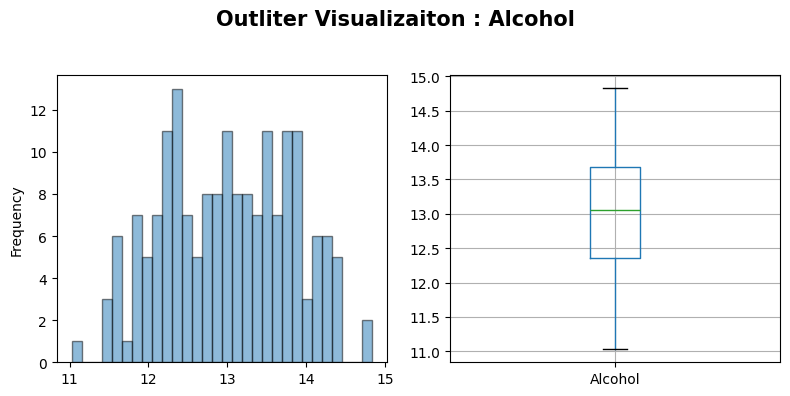

In [40]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,2, figsize=(8,4)) ; plt.subplots_adjust(wspace=0.5);
wine.Alcohol.plot(kind='hist', bins=30, edgecolor='black', alpha=0.5, ax=ax[0]);
# wine.Ash.plot(kind='hist', bins=30, color='red',edgecolor='black', alpha=0.5, ax=ax[0]);
wine.boxplot(column=["Alcohol"], ax=ax[1]);
fig.suptitle('Outliter Visualizaiton : Alcohol', fontsize=15, fontweight='bold')
fig.tight_layout(rect=[0,0,1,0.95])

In [41]:
pd.cut(
    wine.Alcohol,
    bins=[0, 12, 14, 20],
    labels=["low", "mid", "high"]
)

,Alcohol
0,high
1,mid
2,mid
3,high
4,mid
...,...
173,mid
174,mid
175,mid
176,mid
